# Text-to-Brain Metrics v2 (Colab)

## Colab Setup

Run this setup cell once in Colab before the rest of the notebook. It installs the pushed branch that contains the Colab loaders and evaluation code.

In [1]:
import importlib
import sys
import subprocess

BRANCH = "new_text-to-brain_metrics"
REPO_URL = f"git+https://github.com/neurovlm/neurovlm.git@{BRANCH}"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", REPO_URL])

SPIN_PACKAGES = [
    "accelerate",
    "nibabel",
    "nilearn",
    "templateflow",
    "neuromaps",
    "brainspace",
    "nitransforms",
]
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--no-cache-dir",
    *SPIN_PACKAGES,
])
importlib.invalidate_caches()

# If any Hugging Face files/models are private, uncomment these two lines:
# from huggingface_hub import notebook_login
# notebook_login()


## Spin-Test Dependency Check

Run this after setup and before the imports/config cells. If this fails, restart the runtime after the setup cell and run it again.

In [2]:
import importlib
import importlib.metadata as importlib_metadata
import sys
import traceback

SPIN_MODULES = ["neuromaps", "brainspace", "nitransforms", "nibabel", "nilearn", "templateflow"]

try:
    for package in SPIN_MODULES:
        module = importlib.import_module(package)
        version = importlib_metadata.version(package)
        print(f"{package}: {version} ({getattr(module, '__file__', 'built-in')})")

    from neuromaps import transforms
    from brainspace.null_models import SpinPermutations

    assert hasattr(transforms, "mni152_to_fsaverage"), "neuromaps.transforms.mni152_to_fsaverage is unavailable"
    print("Spin-test dependencies OK")
    print("Python:", sys.executable)
except Exception:
    print("Spin-test dependency check failed. Full traceback follows:")
    traceback.print_exc()
    raise


neuromaps: 0.0.5 (/usr/local/lib/python3.12/dist-packages/neuromaps/__init__.py)
brainspace: 0.2.1 (/usr/local/lib/python3.12/dist-packages/brainspace/__init__.py)
nitransforms: 25.1.0 (/usr/local/lib/python3.12/dist-packages/nitransforms/__init__.py)
nibabel: 5.4.2 (/usr/local/lib/python3.12/dist-packages/nibabel/__init__.py)
nilearn: 0.13.1 (/usr/local/lib/python3.12/dist-packages/nilearn/__init__.py)
templateflow: 25.1.2 (/usr/local/lib/python3.12/dist-packages/templateflow/__init__.py)
Spin-test dependencies OK
Python: /usr/bin/python3


In [3]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr, rankdata

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics import (
    pearson_correlation,
    dice_percentile,
    nct_dice_spin_test_surface,
    mni152_to_fsaverage_arrays,
    precompute_spin_permutations,
)


In [4]:
MAX_T2B = None        # full available networks, PubMed test, and NeuroVault sets
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True

DICE_PCT = 90
DICE_SENSITIVITY_PCTS = [80, 85, 90, 95]
SPIN_USE_NEUROMAPS = True   # Colab run: compute surface spin-test p-values
SPIN_REQUIRE_NEUROMAPS = True  # fail loudly instead of silently writing blank spin p-values
SPIN_TEST_N_PERM = 1000
SPIN_TEST_RANDOM_STATE = 13
SPIN_FSAVERAGE_DENSITY = "41k"
SPIN_TRANSFORM_METHOD = "linear"


PUBMED_SURFACE_FILTER_ENABLED = True
PUBMED_MIN_CORTICAL_TOP_MASS_FRACTION = 0.50
NEUROVAULT_IMAGE_SELECTION = "argmax_pearson"  # "first" or "argmax_pearson"
T2B_RANDOM_BASELINE_N = 25
T2B_RANDOM_BASELINE_SEED = 13
T2B_RANDOM_BASELINE_SPEARMAN_MAX_VOXELS = 10000

OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
T2B_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

nvlm = NeuroVLM(device=T2B_DEVICE)
masker = load_masker()
print(f"NeuroVLM inference device: {nvlm.device}")


if SPIN_USE_NEUROMAPS:
    precompute_spin_permutations(
        density=SPIN_FSAVERAGE_DENSITY,
        n_perm=SPIN_TEST_N_PERM,
        random_state=SPIN_TEST_RANDOM_STATE,
    )
    print(f"Precomputed {SPIN_TEST_N_PERM} fsaverage {SPIN_FSAVERAGE_DENSITY} spin permutations.")

print("Ready.")


mask.npz:   0%|          | 0.00/2.93k [00:00<?, ?B/s]

NeuroVLM inference device: cuda


[fetch_files] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/60b684aecb2a5e01fc68b7e1 ...

[fetch_files]  ...done. (2 seconds, 0 min)

[fetch_files] Extracting data from /root/neuromaps-data/9e29c30a00cc86995f334ba48854d362/fsaverage41k.tar.gz...

[fetch_files] .. done.

Precomputed 1000 fsaverage 41k spin permutations.
Ready.


## Evaluation Setup

Text-to-brain predicts a brain map from reference text and compares it with a target brain map. For PubMed, surface Dice and spin-test p-values are only meaningful when the target activation is substantially cortical, because the spin workflow projects MNI volume maps to fsaverage surface. PubMed targets with mostly subcortical top activation are therefore kept for whole-brain Pearson/Spearman but excluded from surface Dice/spin summaries.

For NeuroVault, a paper can have multiple linked images. `NEUROVAULT_IMAGE_SELECTION = "argmax_pearson"` generates one predicted map from the paper text and selects the linked NeuroVault image with the highest Pearson correlation to that prediction. The selected image index and number of candidates are saved for audit. This is a paper-level evaluation instead of arbitrarily using the first uploaded image.


In [6]:
def load_network_test_set_labels_table():
    try:
        return load_dataset("network_test_set_labels"), "huggingface:neurovlm/embedded_text/network_test_set_labels.csv"
    except Exception as hf_error:
        candidates = [
            Path("network_test_set_labels.csv"),
            Path("docs/03_evaluation/network_test_set_labels.csv"),
            Path.cwd() / "network_test_set_labels.csv",
            Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
        ]
        for candidate in candidates:
            if candidate.exists():
                return pd.read_csv(candidate), str(candidate.resolve())
        raise FileNotFoundError(
            "Could not load network_test_set_labels.csv from Hugging Face or local paths. "
            "Upload it to neurovlm/embedded_text as network_test_set_labels.csv. "
            f"Hugging Face error: {hf_error}"
        )


network_labels_df, NETWORK_TEST_SET_SOURCE = load_network_test_set_labels_table()
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_SOURCE}")
display(network_info[["network_key", "display", "short_definition"]])

network_test_set_labels.csv: 0.00B [00:00, ?B/s]

Loaded 8 canonical network labels from huggingface:neurovlm/embedded_text/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [7]:
def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
network_label_rows = (
    network_labels_df
    .drop_duplicates("raw_network_label")
    .set_index("raw_network_label")
)

networks_data = {}
for atlas_name, atlas_latents in all_net_latents.items():
    if not hasattr(atlas_latents, "items"):
        continue
    for raw_label, latent in atlas_latents.items():
        if raw_label not in network_label_rows.index:
            continue
        row = network_label_rows.loc[raw_label]
        sample_name = f"{atlas_name}:{raw_label}"
        networks_data[sample_name] = {
            "latent": latent,
            "short_gt": _normalize_expected_text(row["short_definition"]),
            "long_gt": _normalize_expected_text(row["long_definition"]),
            "network_key": row["network_key"],
            "display": row["network_name"],
            "atlas": atlas_name,
            "raw_network_label": raw_label,
        }

print(f"Networks loaded: {len(networks_data)} labeled maps across {len(all_net_latents)} atlases")
display(pd.DataFrame([
    {"sample": name, "network_key": d["network_key"], "display": d["display"]}
    for name, d in networks_data.items()
]).head())

latent_networks_image.pt:   0%|          | 0.00/339k [00:00<?, ?B/s]

Networks loaded: 119 labeled maps across 10 atlases


,sample,network_key,display
0,Du:CG-OP,cingulo_opercular,Cingulo-Opercular
1,Du:DN-B,default_mode,Default Mode
2,Du:SMOT-B,motor,Motor
3,Du:AUD,auditory,Auditory
4,Du:PM-PPr,motor,Motor


In [8]:
df_pubs = load_dataset("pubmed_text")
if "test" not in df_pubs.columns:
    raise ValueError("pubmed_text must include a boolean 'test' column for PubMed evaluation.")
df_test = df_pubs[df_pubs["test"].fillna(False).astype(bool)].reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_title_col = "name" if "name" in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)
mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]
pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row = pmid_to_row.loc[pmid]
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "short_gt": str(row[_title_col]) if _title_col in row.index else "",
        "long_gt": str(row[_abstract_col]) if _abstract_col in row.index else "",
    })

pubmed_eval = pubmed_data[:MAX_T2B] if MAX_T2B else pubmed_data
print(f"PubMed samples: {len(pubmed_eval)} / {len(pubmed_data)}")

publications.parquet:   0%|          | 0.00/27.5M [00:00<?, ?B/s]

latent_neuro.pt:   0%|          | 0.00/46.2M [00:00<?, ?B/s]

PubMed samples: 2987 / 2987


In [9]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    img_indices = np.asarray([idx for idx in img_indices if idx < len(nv_latents)], dtype=int)
    if len(img_indices) == 0:
        continue
    candidate_latents = nv_latents[img_indices]
    neurovault_data.append({
        "doi": doi,
        "latent": candidate_latents[0],
        "candidate_latents": candidate_latents,
        "candidate_image_indices": img_indices,
        "n_candidate_images": int(len(img_indices)),
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
    })

neurovault_eval = neurovault_data[:MAX_T2B] if MAX_T2B else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")
print(f"NeuroVault image selection mode: {NEUROVAULT_IMAGE_SELECTION}")
if len(neurovault_eval):
    n_multi = sum(d["n_candidate_images"] > 1 for d in neurovault_eval)
    print(f"NeuroVault papers with multiple candidate images in eval set: {n_multi:,}")


publications_neurovault.parquet:   0%|          | 0.00/272k [00:00<?, ?B/s]

images_neurovault.parquet:   0%|          | 0.00/81.1k [00:00<?, ?B/s]

latent_neurovault_images.pt:   0%|          | 0.00/4.89M [00:00<?, ?B/s]

NeuroVault samples: 312 / 312
NeuroVault image selection mode: argmax_pearson
NeuroVault papers with multiple candidate images in eval set: 281


In [10]:
def _as_latent_batch(latents):
    if isinstance(latents, torch.Tensor):
        batch = latents.detach().cpu()
        if batch.dim() == 1:
            batch = batch.unsqueeze(0)
        return batch
    batch = [x.detach().cpu() if isinstance(x, torch.Tensor) else torch.as_tensor(x) for x in latents]
    batch = [x.unsqueeze(0) if x.dim() == 1 else x for x in batch]
    return torch.cat(batch, dim=0)


def decode_latents_to_brain(latents, decoder, batch_size: int = 64) -> np.ndarray:
    batch = _as_latent_batch(latents)
    dec_device = next(decoder.parameters()).device
    chunks = []
    with torch.no_grad():
        for start in range(0, int(batch.shape[0]), batch_size):
            lat = batch[start:start + batch_size].to(dec_device)
            chunks.append(torch.sigmoid(decoder(lat)).detach().cpu())
    return torch.cat(chunks, dim=0).numpy().astype("float32")


def build_surface_eligibility_mask(masker):
    """Return a cortical/surface-oriented mask vector aligned to masker output."""
    try:
        import nibabel as nib
        from nilearn.datasets import fetch_atlas_harvard_oxford
        from nilearn.image import resample_to_img

        mask_img = getattr(masker, "mask_img_", None) or getattr(masker, "mask_img", None)
        atlas = fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
        atlas_img = resample_to_img(atlas.maps, mask_img, interpolation="nearest")
        atlas_data = np.asarray(atlas_img.get_fdata())
        cortical_img = nib.Nifti1Image((atlas_data > 0).astype("int8"), mask_img.affine, mask_img.header)
        cortical_vec = masker.transform(cortical_img).ravel() > 0.5
        method = "harvard_oxford_cortical_thr25"
        if cortical_vec.sum() == 0:
            raise RuntimeError("Harvard-Oxford cortical mask was empty after resampling.")
        return cortical_vec, method
    except Exception as e:
        import nibabel as nib
        mask_img = getattr(masker, "mask_img_", None) or getattr(masker, "mask_img", None)
        mask_data = np.asarray(mask_img.get_fdata()).astype(bool)
        ijk = np.column_stack(np.where(mask_data))
        xyz = nib.affines.apply_affine(mask_img.affine, ijk)
        central_subcortical_proxy = (
            (np.abs(xyz[:, 0]) < 35)
            & (np.abs(xyz[:, 1]) < 45)
            & (np.abs(xyz[:, 2]) < 35)
        )
        inferior_proxy = xyz[:, 2] < -35
        cortical_vec = (~central_subcortical_proxy) & (~inferior_proxy)
        print(f"Surface eligibility atlas unavailable; using MNI cortical-shell fallback. Reason: {type(e).__name__}: {e}")
        return cortical_vec, "mni_cortical_shell_fallback"


SURFACE_ELIGIBILITY_MASK, SURFACE_ELIGIBILITY_METHOD = build_surface_eligibility_mask(masker)
print(f"Surface eligibility mask: {SURFACE_ELIGIBILITY_METHOD}; cortical voxels={int(SURFACE_ELIGIBILITY_MASK.sum()):,}")


def cortical_top_mass_fraction(brain_true: np.ndarray, pct: float = DICE_PCT):
    values = np.asarray(brain_true, dtype=float).ravel()
    positive = np.clip(values, 0, None)
    if positive.size != SURFACE_ELIGIBILITY_MASK.size:
        return np.nan, "surface_mask_shape_mismatch"
    threshold = np.percentile(positive, pct)
    top = positive >= threshold
    if not np.any(top):
        return np.nan, "no_top_activation_voxels"
    top_mass = float(positive[top].sum())
    if top_mass <= 0:
        return np.nan, "zero_top_activation_mass"
    cortical_mass = float(positive[top & SURFACE_ELIGIBILITY_MASK].sum())
    return cortical_mass / top_mass, "ok"


def surface_metric_eligibility(dataset_name: str, brain_true: np.ndarray):
    frac, reason = cortical_top_mass_fraction(brain_true, pct=DICE_PCT)
    if dataset_name != "pubmed" or not PUBMED_SURFACE_FILTER_ENABLED:
        return True, frac, "not_pubmed_or_filter_disabled"
    if not np.isfinite(frac):
        return False, frac, reason
    if frac < PUBMED_MIN_CORTICAL_TOP_MASS_FRACTION:
        return False, frac, f"pubmed_low_cortical_top_mass_fraction<{PUBMED_MIN_CORTICAL_TOP_MASS_FRACTION}"
    return True, frac, "ok"


def select_true_brain_for_eval(true_latent, decoder, brain_pred, candidate_latents=None, candidate_indices=None, selection_mode="first"):
    latents = candidate_latents if candidate_latents is not None else true_latent
    true_brains = decode_latents_to_brain(latents, decoder)
    n_candidates = int(true_brains.shape[0])
    if candidate_indices is None:
        candidate_indices = np.arange(n_candidates)
    candidate_indices = np.asarray(candidate_indices)

    scores = np.asarray([pearson_correlation(brain, brain_pred) for brain in true_brains], dtype=float)
    if selection_mode == "argmax_pearson" and n_candidates > 1:
        selected_pos = int(np.nanargmax(scores))
    else:
        selected_pos = 0
    return {
        "brain_true": true_brains[selected_pos],
        "selected_candidate_position": selected_pos,
        "selected_candidate_index": int(candidate_indices[selected_pos]) if selected_pos < len(candidate_indices) else selected_pos,
        "selected_candidate_pearson": float(scores[selected_pos]) if len(scores) else np.nan,
        "n_candidate_images": n_candidates,
        "candidate_pearson_max": float(np.nanmax(scores)) if len(scores) else np.nan,
        "candidate_pearson_mean": float(np.nanmean(scores)) if len(scores) else np.nan,
    }


def run_t2b(
    name,
    text_input,
    true_latent,
    dataset_name="unknown",
    candidate_latents=None,
    candidate_indices=None,
    neurovault_selection_mode="first",
):
    try:
        gen_result = nvlm.text(text_input).to_brain(head="mse")
        nifti_pred = gen_result.to_nifti(index=0)
        brain_pred = masker.transform(nifti_pred).ravel().astype("float32")

        dec = gen_result.decoder
        selection_mode = neurovault_selection_mode if dataset_name == "neurovault" else "first"
        selected = select_true_brain_for_eval(
            true_latent=true_latent,
            decoder=dec,
            brain_pred=brain_pred,
            candidate_latents=candidate_latents,
            candidate_indices=candidate_indices,
            selection_mode=selection_mode,
        )
        brain_true = selected["brain_true"]
        nifti_true = masker.inverse_transform(brain_true.reshape(1, -1))

        pearson_r = float(pearson_correlation(brain_true, brain_pred))
        spearman_rho, _ = spearmanr(brain_true.ravel(), brain_pred.ravel())
        surface_eligible, cortical_frac, surface_reason = surface_metric_eligibility(dataset_name, brain_true)

        dice_val = np.nan
        dice_method = "not_run_surface_ineligible" if not surface_eligible else "volume_masker_percentile"
        pred_lh = pred_rh = true_lh = true_rh = None
        spin_p_value = np.nan
        spin_method = "not_run_surface_ineligible" if not surface_eligible else "not_run"
        spin_significant = False

        if surface_eligible:
            dice_val = dice_percentile(brain_pred, brain_true, pct=DICE_PCT)
            if SPIN_USE_NEUROMAPS:
                try:
                    pred_lh, pred_rh = mni152_to_fsaverage_arrays(nifti_pred, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                    true_lh, true_rh = mni152_to_fsaverage_arrays(nifti_true, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                    nct = nct_dice_spin_test_surface(
                        pred_lh, pred_rh, true_lh, true_rh,
                        pct=DICE_PCT,
                        n_perm=SPIN_TEST_N_PERM,
                        random_state=SPIN_TEST_RANDOM_STATE,
                        density=SPIN_FSAVERAGE_DENSITY,
                    )
                    dice_val = nct.dice_pct
                    dice_method = "surface_fsaverage_percentile_nct"
                    spin_p_value = nct.spin_p_value
                    spin_method = nct.spin_method
                    spin_significant = nct.spin_significant
                except ImportError as e:
                    spin_method = f"not_run_missing_dependency:{e.name}: {e}"
                    if globals().get("SPIN_REQUIRE_NEUROMAPS", False):
                        raise RuntimeError(f"Spin dependency failed for {name}: {spin_method}") from e
                except Exception as e:
                    spin_method = f"not_run_nct_error:{type(e).__name__}: {e}"
                    if globals().get("SPIN_REQUIRE_NEUROMAPS", False):
                        raise

        return {
            "name": name,
            "text_input": text_input[:120],
            "pearson_r": pearson_r,
            "spearman_rho": float(spearman_rho),
            f"dice_pct{DICE_PCT}": float(dice_val) if np.isfinite(dice_val) else np.nan,
            "dice_method": dice_method,
            "spin_p_value": float(spin_p_value) if np.isfinite(spin_p_value) else np.nan,
            "spin_significant": bool(spin_significant),
            "spin_method": spin_method,
            "surface_metric_eligible": bool(surface_eligible),
            "surface_metric_skip_reason": surface_reason,
            "cortical_top_mass_fraction": float(cortical_frac) if np.isfinite(cortical_frac) else np.nan,
            "surface_eligibility_method": SURFACE_ELIGIBILITY_METHOD,
            "neurovault_selection_mode": selection_mode if dataset_name == "neurovault" else "not_applicable",
            "n_candidate_images": selected["n_candidate_images"],
            "selected_candidate_position": selected["selected_candidate_position"],
            "selected_candidate_index": selected["selected_candidate_index"],
            "selected_candidate_pearson": selected["selected_candidate_pearson"],
            "candidate_pearson_max": selected["candidate_pearson_max"],
            "candidate_pearson_mean": selected["candidate_pearson_mean"],
            "_brain_pred": brain_pred,
            "_brain_true": brain_true,
            "_pred_lh": pred_lh,
            "_pred_rh": pred_rh,
            "_true_lh": true_lh,
            "_true_rh": true_rh,
        }
    except Exception as e:
        print(f"[T2B error] {name}: {type(e).__name__}: {e}")
        if globals().get("SPIN_USE_NEUROMAPS", False) and globals().get("SPIN_REQUIRE_NEUROMAPS", False):
            raise
        return None


[fetch_atlas_harvard_oxford] Added README.md to /root/nilearn_data

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford] Downloaded 14835712 of 25716861 bytes (57.7%%,    0.7s remaining)

[fetch_atlas_harvard_oxford]  ...done. (2 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

Surface eligibility mask: harvard_oxford_cortical_thr25; cortical voxels=16,145


In [11]:
t2b_frames = []

if RUN_NETWORKS:
    records = []
    for net_name, d in tqdm(networks_data.items(), desc="Networks T2B"):
        rec = run_t2b(net_name, d["long_gt"], d["latent"], dataset_name="networks")
        if rec is not None:
            records.append(rec)
    t2b_net_df = pd.DataFrame(records)
    t2b_net_df["dataset"] = "networks"
    t2b_frames.append(t2b_net_df)

if RUN_PUBMED:
    records = []
    for d in tqdm(pubmed_eval, desc="PubMed T2B"):
        rec = run_t2b(str(d["pmid"]), d["short_gt"] + " [SEP] " + d["long_gt"], d["latent"], dataset_name="pubmed")
        if rec is not None:
            records.append(rec)
    t2b_pubmed_df = pd.DataFrame(records)
    t2b_pubmed_df["dataset"] = "pubmed"
    t2b_frames.append(t2b_pubmed_df)

if RUN_NEUROVAULT:
    records = []
    for d in tqdm(neurovault_eval, desc="NeuroVault T2B"):
        rec = run_t2b(
            str(d["doi"]),
            d["short_gt"] + " [SEP] " + d["long_gt"],
            d["latent"],
            dataset_name="neurovault",
            candidate_latents=d.get("candidate_latents"),
            candidate_indices=d.get("candidate_image_indices"),
            neurovault_selection_mode=NEUROVAULT_IMAGE_SELECTION,
        )
        if rec is not None:
            records.append(rec)
    t2b_nv_df = pd.DataFrame(records)
    t2b_nv_df["dataset"] = "neurovault"
    t2b_frames.append(t2b_nv_df)

t2b_all = pd.concat(t2b_frames, ignore_index=True)
t2b_all.head()


Networks T2B:   0%|          | 0/119 [00:00<?, ?it/s]

[fetch_files] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/60b684c03a6df1020ed525f6 ...

[fetch_files]  ...done. (2 seconds, 0 min)

[fetch_files] Extracting data from /root/neuromaps-data/5bb728f5dc8506afb8459c2c4450bd86/regfusion.tar.gz...

[fetch_files] .. done.

PubMed T2B:   0%|          | 0/2987 [00:00<?, ?it/s]

NeuroVault T2B:   0%|          | 0/312 [00:00<?, ?it/s]

,name,text_input,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,surface_metric_eligible,...,selected_candidate_pearson,candidate_pearson_max,candidate_pearson_mean,_brain_pred,_brain_true,_pred_lh,_pred_rh,_true_lh,_true_rh,dataset
0,Du:CG-OP,The cingulo-opercular network includes dorsal ...,0.313852,0.567136,0.318931,surface_fsaverage_percentile_nct,0.001998,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.313852,0.313852,0.313852,"[3.2545843e-06, 0.022498773, 0.023728294, 4.80...","[1.3146543e-17, 1.0277482e-06, 1.0417257e-05, ...","[0.026976971, 0.026646195, 0.06443034, 0.04130...","[0.032546945, 0.07813083, 0.019515084, 0.06247...","[0.0015657393, 0.00045247594, 0.37159526, 0.00...","[0.0038916084, 7.685055e-05, 0.00090343785, 0....",networks
1,Du:DN-B,The default mode network includes medial prefr...,0.333324,0.631819,0.414378,surface_fsaverage_percentile_nct,0.002997,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.333324,0.333324,0.333324,"[1.5073856e-06, 0.04148489, 0.039975435, 3.242...","[4.7605954e-20, 0.018851157, 0.0037589336, 6.9...","[0.011652593, 0.018691791, 0.023020804, 0.0505...","[0.02047826, 0.042466022, 0.009320647, 0.03094...","[2.2295081e-09, 2.8574743e-08, 1.3823783e-06, ...","[8.012874e-07, 7.1395425e-07, 1.3709219e-07, 8...",networks
2,Du:SMOT-B,The motor or somatomotor network includes prim...,0.197300,0.562804,0.249725,surface_fsaverage_percentile_nct,0.185814,False,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.197300,0.197300,0.197300,"[9.712946e-07, 0.0045603802, 0.0063624824, 1.4...","[3.7144917e-20, 3.1787724e-07, 7.7678754e-07, ...","[0.2362358, 0.02277671, 0.15076138, 0.00965468...","[0.15418962, 0.051781945, 0.068913475, 0.01897...","[0.00045069194, 9.519939e-09, 0.0004089367, 7....","[0.0006649389, 3.493841e-07, 0.54254514, 2.594...",networks
3,Du:AUD,The auditory network includes primary auditory...,0.642937,0.699131,0.802026,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.642937,0.642937,0.642937,"[2.0208854e-06, 0.17914297, 0.17343713, 4.1845...","[1.966833e-25, 0.00014512535, 0.00038014122, 5...","[0.011207273, 0.0050929626, 0.03196819, 0.0157...","[0.014900308, 0.019930148, 0.03411152, 0.00880...","[9.544657e-11, 7.3868975e-08, 9.2570196e-10, 2...","[6.8256294e-09, 6.751389e-08, 4.592289e-06, 4....",networks
4,Du:PM-PPr,The motor or somatomotor network includes prim...,0.263603,0.505386,0.394727,surface_fsaverage_percentile_nct,0.048951,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.263603,0.263603,0.263603,"[9.712946e-07, 0.0045603802, 0.0063624824, 1.4...","[7.196587e-21, 1.3443685e-09, 1.9521172e-08, 1...","[0.2362358, 0.02277671, 0.15076138, 0.00965468...","[0.15418962, 0.051781945, 0.068913475, 0.01897...","[0.044812463, 0.20633502, 0.000111464484, 7.05...","[0.2200205, 0.13150868, 0.008307587, 7.9469155...",networks


In [12]:
def _random_baseline_voxel_index(n_voxels: int):
    n = min(int(T2B_RANDOM_BASELINE_SPEARMAN_MAX_VOXELS), int(n_voxels))
    rng = np.random.default_rng(T2B_RANDOM_BASELINE_SEED)
    return np.sort(rng.choice(n_voxels, size=n, replace=False)) if n < n_voxels else np.arange(n_voxels)


def _zscore_rows(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, dtype="float32")
    arr = arr - arr.mean(axis=1, keepdims=True)
    std = arr.std(axis=1, keepdims=True)
    std[std < 1e-8] = 1.0
    return arr / std


def _rank_zscore_rows(arr: np.ndarray) -> np.ndarray:
    ranks = np.vstack([rankdata(row, method="average") for row in np.asarray(arr, dtype="float32")]).astype("float32")
    return _zscore_rows(ranks)


def add_random_correlation_baseline(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in [
        "pearson_baseline_actual", "pearson_random_mean", "pearson_random_std", "pearson_minus_random", "pearson_random_percentile",
        "spearman_baseline_actual", "spearman_random_mean", "spearman_random_std", "spearman_minus_random", "spearman_random_percentile",
    ]:
        out[col] = np.nan
    if out.empty:
        return out

    n_voxels = len(out.iloc[0]["_brain_pred"])
    voxel_idx = _random_baseline_voxel_index(n_voxels)
    rng = np.random.default_rng(T2B_RANDOM_BASELINE_SEED)

    for dataset, sub in out.groupby("dataset", sort=False):
        idxs = sub.index.to_numpy()
        if len(idxs) < 2:
            continue
        pred_subset = np.vstack([out.at[idx, "_brain_pred"][voxel_idx] for idx in idxs])
        true_subset = np.vstack([out.at[idx, "_brain_true"][voxel_idx] for idx in idxs])
        pred_z = _zscore_rows(pred_subset)
        true_z = _zscore_rows(true_subset)
        pred_rank_z = _rank_zscore_rows(pred_subset)
        true_rank_z = _rank_zscore_rows(true_subset)
        denom = float(len(voxel_idx))

        for pos, idx in enumerate(tqdm(idxs, desc=f"{dataset} random correlation baseline")):
            pool = np.array([p for p in range(len(idxs)) if p != pos], dtype=int)
            sampled_pos = rng.choice(pool, size=T2B_RANDOM_BASELINE_N, replace=len(pool) < T2B_RANDOM_BASELINE_N)
            pearson_vals = (true_z[sampled_pos] @ pred_z[pos]) / denom
            spearman_vals = (true_rank_z[sampled_pos] @ pred_rank_z[pos]) / denom
            actual_pearson_subset = float((true_z[pos] @ pred_z[pos]) / denom)
            actual_spearman_subset = float((true_rank_z[pos] @ pred_rank_z[pos]) / denom)

            out.at[idx, "pearson_baseline_actual"] = actual_pearson_subset
            out.at[idx, "pearson_random_mean"] = float(np.nanmean(pearson_vals))
            out.at[idx, "pearson_random_std"] = float(np.nanstd(pearson_vals))
            out.at[idx, "pearson_minus_random"] = float(actual_pearson_subset - np.nanmean(pearson_vals))
            out.at[idx, "pearson_random_percentile"] = float((np.sum(pearson_vals < actual_pearson_subset) + 1) / (np.sum(np.isfinite(pearson_vals)) + 1))
            out.at[idx, "spearman_baseline_actual"] = actual_spearman_subset
            out.at[idx, "spearman_random_mean"] = float(np.nanmean(spearman_vals))
            out.at[idx, "spearman_random_std"] = float(np.nanstd(spearman_vals))
            out.at[idx, "spearman_minus_random"] = float(actual_spearman_subset - np.nanmean(spearman_vals))
            out.at[idx, "spearman_random_percentile"] = float((np.sum(spearman_vals < actual_spearman_subset) + 1) / (np.sum(np.isfinite(spearman_vals)) + 1))
    out["random_baseline_n"] = T2B_RANDOM_BASELINE_N
    out["random_baseline_n_voxels"] = len(voxel_idx)
    return out


t2b_all = add_random_correlation_baseline(t2b_all)
_public_cols = [c for c in t2b_all.columns if not c.startswith("_")]
t2b_all[_public_cols].to_csv(OUTPUT_DIR / "text_to_brain_metrics_v2.csv", index=False)
t2b_all[_public_cols].head()


networks random correlation baseline:   0%|          | 0/119 [00:00<?, ?it/s]

pubmed random correlation baseline:   0%|          | 0/2987 [00:00<?, ?it/s]

neurovault random correlation baseline:   0%|          | 0/312 [00:00<?, ?it/s]

,name,text_input,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,surface_metric_eligible,...,pearson_random_std,pearson_minus_random,pearson_random_percentile,spearman_baseline_actual,spearman_random_mean,spearman_random_std,spearman_minus_random,spearman_random_percentile,random_baseline_n,random_baseline_n_voxels
0,Du:CG-OP,The cingulo-opercular network includes dorsal ...,0.313852,0.567136,0.318931,surface_fsaverage_percentile_nct,0.001998,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.112295,0.238484,0.923077,0.572967,0.306927,0.148531,0.266040,0.961538,25,10000
1,Du:DN-B,The default mode network includes medial prefr...,0.333324,0.631819,0.414378,surface_fsaverage_percentile_nct,0.002997,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.140337,0.309356,0.961538,0.631314,0.356356,0.217216,0.274958,0.923077,25,10000
2,Du:SMOT-B,The motor or somatomotor network includes prim...,0.197300,0.562804,0.249725,surface_fsaverage_percentile_nct,0.185814,False,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.205392,0.146998,0.846154,0.562896,0.206137,0.258381,0.356759,0.884615,25,10000
3,Du:AUD,The auditory network includes primary auditory...,0.642937,0.699131,0.802026,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.185234,0.552935,1.000000,0.700019,0.380725,0.143818,0.319294,0.961538,25,10000
4,Du:PM-PPr,The motor or somatomotor network includes prim...,0.263603,0.505386,0.394727,surface_fsaverage_percentile_nct,0.048951,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,True,...,0.208440,0.194793,0.846154,0.502941,0.214783,0.274484,0.288158,0.807692,25,10000


## Metric Summary

- **Pearson r** checks linear whole-brain voxelwise similarity between predicted and target maps. The random baseline uses a fixed voxel subset for speed; `pearson_minus_random > 0` means the prediction is more similar to its own target than to random targets from the same dataset.
- **Spearman rho** checks rank-order whole-brain similarity. The random baseline also uses the fixed voxel subset; `spearman_minus_random > 0` is the main interpretation.
- **Dice pct** checks overlap among the strongest activation regions at percentile `DICE_PCT`. PubMed samples that are mostly subcortical are excluded because surface projection would not fairly represent them.
- **Spin p-value** tests whether surface Dice is stronger than spatially rotated null maps. Lower is better; `p < 0.05` is conventionally significant. It is only interpreted for surface-eligible samples.


In [13]:
dice_col = f"dice_pct{DICE_PCT}"
metric_cols = [
    "pearson_r", "pearson_baseline_actual", "pearson_random_mean", "pearson_minus_random", "pearson_random_percentile",
    "spearman_rho", "spearman_baseline_actual", "spearman_random_mean", "spearman_minus_random", "spearman_random_percentile",
    dice_col, "spin_p_value",
]
summary = t2b_all.groupby("dataset")[metric_cols].agg(["mean", "std", "count"]).round(3)
display(summary)
display(t2b_all.groupby("dataset")["spin_significant"].sum().rename("n_spin_p_lt_0_05"))
display(t2b_all.groupby(["dataset", "surface_metric_eligible", "surface_metric_skip_reason"]).size().rename("n"))
display(t2b_all.groupby(["dataset", "spin_method"]).size().rename("n"))
if "neurovault" in set(t2b_all["dataset"]):
    display(t2b_all[t2b_all["dataset"] == "neurovault"][["n_candidate_images", "selected_candidate_position", "selected_candidate_pearson"]].describe().round(3))


pearson_r              pearson_baseline_actual               \
                mean    std count                    mean    std count   
dataset                                                                  
networks       0.362  0.184   119                   0.363  0.184   119   
neurovault     0.302  0.139   312                   0.302  0.139   312   
pubmed         0.322  0.184  2987                   0.323  0.184  2987   

           pearson_random_mean              pearson_minus_random  ...  \
                          mean    std count                 mean  ...   
dataset                                                           ...   
networks                 0.076  0.031   119                0.287  ...   
neurovault               0.156  0.037   312                0.146  ...   
pubmed                   0.186  0.044  2987                0.137  ...   

           spearman_minus_random spearman_random_percentile               \
                           count                       mean    std count   
dataset                                                                    
networks                     119                      0.830  0.166   119   
neurovault                   312                      0.694  0.259   312   
pubmed                      2987                      0.683  0.276  2987   

           dice_pct90              spin_p_value               
                 mean    std count         mean    std count  
dataset                                                       
networks        0.443  0.189   119        0.065  0.145   119  
neurovault      0.311  0.161   312        0.112  0.204   312  
pubmed          0.290  0.162  2543        0.149  0.245  2543  

[3 rows x 36 columns]

,n_spin_p_lt_0_05
dataset,
networks,92
neurovault,208
pubmed,1523


dataset     surface_metric_eligible  surface_metric_skip_reason               
networks    True                     not_pubmed_or_filter_disabled                 119
neurovault  True                     not_pubmed_or_filter_disabled                 312
pubmed      False                    pubmed_low_cortical_top_mass_fraction<0.5     444
            True                     ok                                           2543
Name: n, dtype: int64

dataset     spin_method                                      
networks    neuromaps_mni152_to_fsaverage_41k+brainspace_spin     119
neurovault  neuromaps_mni152_to_fsaverage_41k+brainspace_spin     312
pubmed      neuromaps_mni152_to_fsaverage_41k+brainspace_spin    2543
            not_run_surface_ineligible                            444
Name: n, dtype: int64

,n_candidate_images,selected_candidate_position,selected_candidate_pearson
count,312.000,312.000,312.000
mean,10.202,3.808,0.302
std,13.685,6.355,0.139
min,1.000,0.000,-0.095
25%,3.000,0.000,0.216
50%,6.000,2.000,0.305
75%,12.000,4.000,0.397
max,100.000,56.000,0.628


## Correlation Random Baseline Plot

This plot compares each sample's actual Pearson/Spearman score against random target maps from the same dataset, using a fixed voxel subset for speed. If actual scores are above random, the model is capturing sample-specific brain structure rather than only generic dataset-level activation patterns.


/tmp/ipykernel_1035/491468519.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, positions=positions, labels=labels, showmeans=True)
/tmp/ipykernel_1035/491468519.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, positions=positions, labels=labels, showmeans=True)


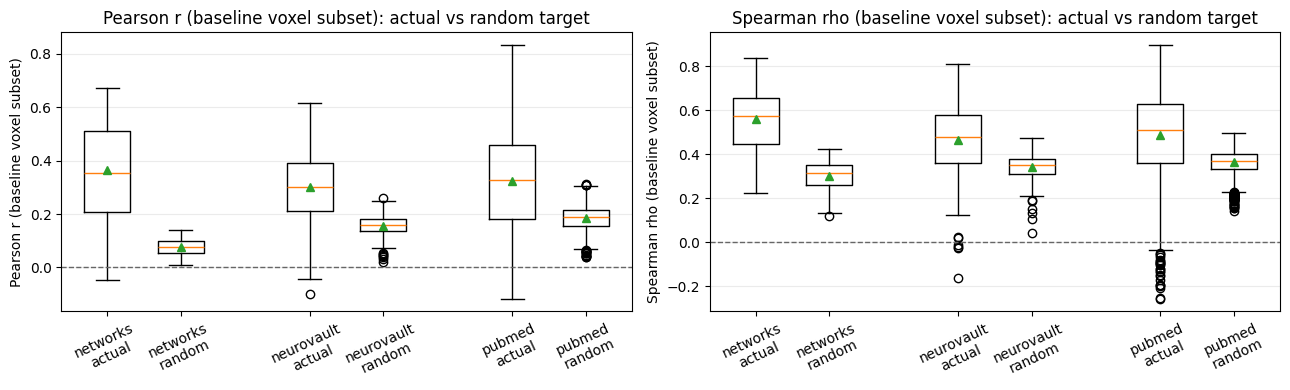

In [14]:
def _finite_box_values(values):
    vals = pd.Series(values).dropna().to_numpy()
    return vals if len(vals) else np.asarray([np.nan])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, random_col, title in [
    (axes[0], "pearson_baseline_actual", "pearson_random_mean", "Pearson r (baseline voxel subset)"),
    (axes[1], "spearman_baseline_actual", "spearman_random_mean", "Spearman rho (baseline voxel subset)"),
]:
    data = []
    labels = []
    positions = []
    pos = 1
    for dataset, sub in t2b_all.groupby("dataset"):
        data.extend([_finite_box_values(sub[metric]), _finite_box_values(sub[random_col])])
        labels.extend([f"{dataset}\nactual", f"{dataset}\nrandom"])
        positions.extend([pos, pos + 0.8])
        pos += 2.2
    ax.boxplot(data, positions=positions, labels=labels, showmeans=True)
    ax.axhline(0, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: actual vs random target")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_correlation_random_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice Threshold Sensitivity

This recomputes Dice and spin significance across several percentile thresholds. Stable conclusions across thresholds are stronger than a result that only appears at one arbitrary cutoff. PubMed rows failing the cortical surface-eligibility check remain excluded at every threshold.


In [15]:
def _sensitivity_rows_for_df(df, dataset, pcts=DICE_SENSITIVITY_PCTS):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{dataset} Dice sensitivity"):
        for pct in pcts:
            if not bool(row.get("surface_metric_eligible", True)):
                rows.append({
                    "dataset": dataset,
                    "sample": row["name"],
                    "pct": pct,
                    "top_fraction": (100 - pct) / 100,
                    "dice": np.nan,
                    "spin_p_value": np.nan,
                    "spin_significant": False,
                    "method": "not_run_surface_ineligible",
                })
                continue
            has_surface = all(row.get(k) is not None for k in ["_pred_lh", "_pred_rh", "_true_lh", "_true_rh"])
            spin_p = np.nan
            spin_sig = False
            method = "volume_masker_percentile"
            if has_surface:
                try:
                    nct = nct_dice_spin_test_surface(
                        row["_pred_lh"], row["_pred_rh"], row["_true_lh"], row["_true_rh"],
                        pct=pct, n_perm=SPIN_TEST_N_PERM, random_state=SPIN_TEST_RANDOM_STATE,
                        density=SPIN_FSAVERAGE_DENSITY,
                    )
                    dice_val = nct.dice_pct
                    spin_p = nct.spin_p_value
                    spin_sig = nct.spin_significant
                    method = "surface_fsaverage_percentile_nct"
                except Exception as e:
                    if globals().get("SPIN_REQUIRE_NEUROMAPS", False):
                        raise
                    dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            else:
                dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            rows.append({
                "dataset": dataset,
                "sample": row["name"],
                "pct": pct,
                "top_fraction": (100 - pct) / 100,
                "dice": float(dice_val),
                "spin_p_value": float(spin_p) if np.isfinite(spin_p) else np.nan,
                "spin_significant": bool(spin_sig),
                "method": method,
            })
    return rows

sensitivity_records = []
for dataset, sub in t2b_all.groupby("dataset"):
    sensitivity_records.extend(_sensitivity_rows_for_df(sub.reset_index(drop=True), dataset))
t2b_sensitivity_df = pd.DataFrame(sensitivity_records)
display(t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(dice_mean=("dice", "mean"), dice_std=("dice", "std"), sig_rate=("spin_significant", "mean"), n_surface_metric=("dice", "count"), n_total=("sample", "count")).round(3))


networks Dice sensitivity:   0%|          | 0/119 [00:00<?, ?it/s]

neurovault Dice sensitivity:   0%|          | 0/312 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/2987 [00:00<?, ?it/s]

dice_mean  dice_std  sig_rate  n_surface_metric  n_total
dataset    pct                                                          
networks   80       0.562     0.156     0.840               119      119
           85       0.516     0.170     0.790               119      119
           90       0.443     0.189     0.773               119      119
           95       0.310     0.199     0.689               119      119
neurovault 80       0.392     0.143     0.638               312      312
           85       0.351     0.150     0.644               312      312
           90       0.311     0.161     0.667               312      312
           95       0.247     0.169     0.631               312      312
pubmed     80       0.400     0.151     0.552              2543     2987
           85       0.350     0.157     0.535              2543     2987
           90       0.290     0.162     0.510              2543     2987
           95       0.210     0.162     0.452              2543     2987

## Metric Distribution Plot

Pearson and Spearman are shown as improvement over the random baseline. Values above zero indicate better-than-random target matching. Dice and spin p-value use only surface-eligible rows; missing PubMed values usually indicate mostly subcortical target activation.


/tmp/ipykernel_1035/505958949.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_1035/505958949.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_1035/505958949.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_1035/505958949.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups,

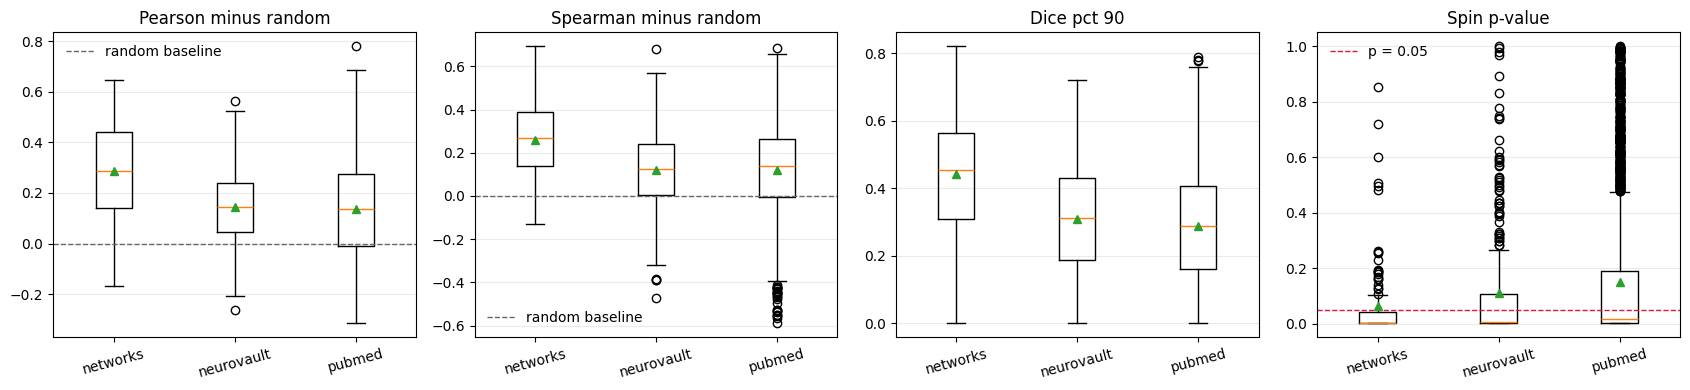

In [16]:
def _finite_box_values(values):
    vals = pd.Series(values).dropna().to_numpy()
    return vals if len(vals) else np.asarray([np.nan])

dice_col = f"dice_pct{DICE_PCT}"
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
plot_df = t2b_all.copy()
for ax, metric, title in zip(axes, ["pearson_minus_random", "spearman_minus_random", dice_col, "spin_p_value"], ["Pearson minus random", "Spearman minus random", f"Dice pct {DICE_PCT}", "Spin p-value"]):
    groups = [_finite_box_values(g[metric]) for _, g in plot_df.groupby("dataset")]
    labels = [k for k, _ in plot_df.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    if metric in {"pearson_minus_random", "spearman_minus_random"}:
        ax.axhline(0, color="0.4", linestyle="--", linewidth=1, label="random baseline")
        ax.legend(frameon=False)
    if metric == "spin_p_value":
        ax.axhline(0.05, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
        ax.legend(frameon=False)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice Threshold Sensitivity Plot

The left panel shows mean Dice as the activation percentile threshold changes; the right panel shows the fraction of samples with spin-test `p < 0.05`. If the conclusion changes sharply across thresholds, the Dice result is threshold-sensitive. Surface-ineligible PubMed rows remain excluded from Dice/spin at all thresholds.


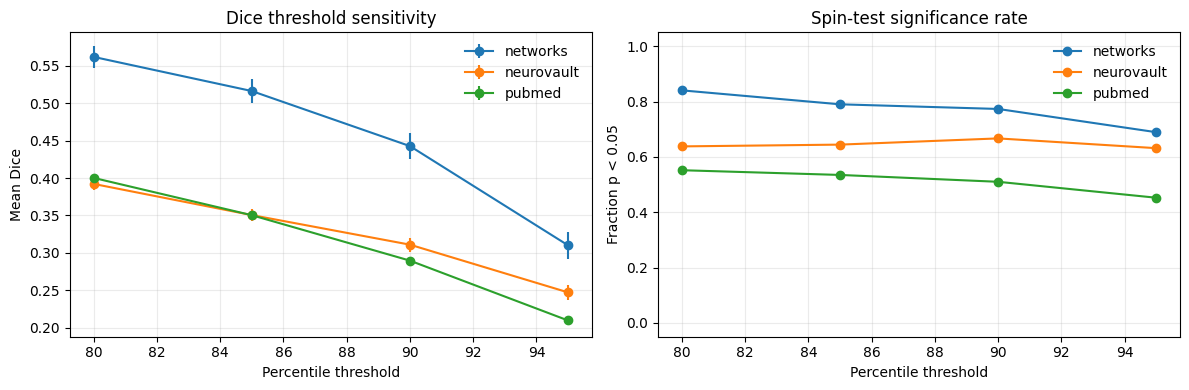

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_plot = t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(
    dice_mean=("dice", "mean"),
    dice_sem=("dice", lambda x: x.std() / np.sqrt(max(x.count(), 1))),
    sig_rate=("spin_significant", "mean"),
).reset_index()
for dataset, sub in summary_plot.groupby("dataset"):
    axes[0].errorbar(sub["pct"], sub["dice_mean"], yerr=sub["dice_sem"], marker="o", label=dataset)
    axes[1].plot(sub["pct"], sub["sig_rate"], marker="o", label=dataset)
axes[0].set_xlabel("Percentile threshold")
axes[0].set_ylabel("Mean Dice")
axes[0].set_title("Dice threshold sensitivity")
axes[1].set_xlabel("Percentile threshold")
axes[1].set_ylabel("Fraction p < 0.05")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Spin-test significance rate")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_pvalue_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice vs Spin Significance

This scatterplot shows whether larger activation overlap also corresponds to stronger spatial significance. The horizontal line marks `p = 0.05`; points above it are significant after the spin-test null model. Color shows Pearson improvement over random target maps.


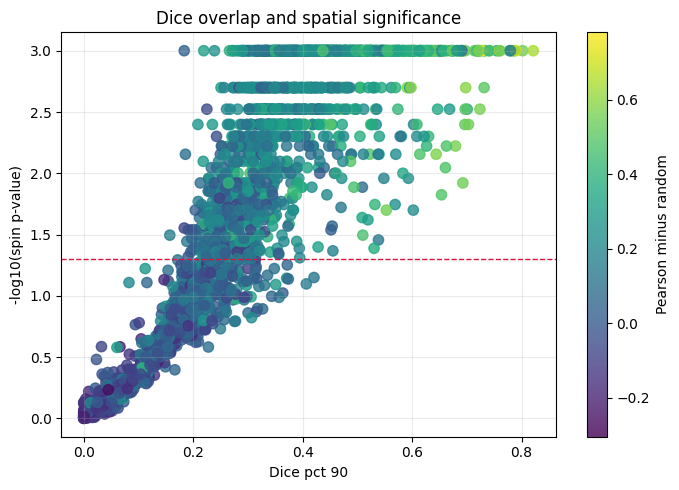

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = t2b_all.dropna(subset=[dice_col, "spin_p_value", "pearson_minus_random"])
if len(plot_df):
    scatter = ax.scatter(plot_df[dice_col], -np.log10(plot_df["spin_p_value"].clip(lower=1e-6)), c=plot_df["pearson_minus_random"], cmap="viridis", s=55, alpha=0.8)
    cb = fig.colorbar(scatter, ax=ax)
    cb.set_label("Pearson minus random")
else:
    ax.text(0.5, 0.5, "No eligible finite Dice/spin rows", ha="center", va="center", transform=ax.transAxes)
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel(f"Dice pct {DICE_PCT}")
ax.set_ylabel("-log10(spin p-value)")
ax.set_title("Dice overlap and spatial significance")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_vs_pvalue.png", dpi=150, bbox_inches="tight")
plt.show()
